In [1]:
import pandas as pd

url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(url_red, sep=";")
white = pd.read_csv(url_white, sep=";")

Encode color variable to 0/1, the concat the datasets

In [2]:
red["color"] = 0
white["color"] = 1
wine = pd.concat([red, white], ignore_index=True)
wine = wine.sample(frac=1, random_state=1234).reset_index(drop=True)
wine.shape

(6497, 13)

In [3]:
X = wine.drop("quality", axis=1)
y = wine["quality"]
X.shape, y.shape

((6497, 12), (6497,))

In [4]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
0,6.0,0.33,0.20,1.80,0.031,49.0,159.0,0.99190,3.41,0.53,11.0,1
1,7.2,0.29,0.20,7.70,0.046,51.0,174.0,0.99582,3.16,0.52,9.5,1
2,6.7,0.47,0.29,4.75,0.034,29.0,134.0,0.99056,3.29,0.46,13.0,1
3,7.6,0.43,0.31,2.10,0.069,13.0,74.0,0.99580,3.26,0.54,9.9,0
4,6.8,0.68,0.09,3.90,0.068,15.0,29.0,0.99524,3.41,0.52,11.1,0


In [5]:
from sklearn.model_selection import train_test_split

seed = 1234

# first split test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

# split train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_train_full,
)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=1234,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_val_pred = rf.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred, average="weighted", zero_division=0))
print("Validation Recall:", recall_score(y_val, y_val_pred, average="weighted", zero_division=0))
print("Validation F1:", f1_score(y_val, y_val_pred, average="weighted", zero_division=0))

Validation Accuracy: 0.6492307692307693
Validation Precision: 0.6560963730242597
Validation Recall: 0.6492307692307693
Validation F1: 0.63435552731458


In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

param_grid = [
    {"n_estimators": 50, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 20, "min_samples_split": 5, "min_samples_leaf": 2},
]

for params in param_grid:
    rf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=1234,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)

    results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_precision": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="val_f1", ascending=False).reset_index(drop=True)
results_df

,n_estimators,max_depth,min_samples_split,min_samples_leaf,val_accuracy,val_precision,val_recall,val_f1
0,50,NaN,2,1,0.660769,0.671057,0.660769,0.647936
1,200,NaN,2,1,0.649231,0.655944,0.649231,0.634504
2,100,NaN,2,1,0.649231,0.656096,0.649231,0.634356
3,100,20.0,5,2,0.645385,0.658432,0.645385,0.625447
4,100,10.0,2,1,0.626154,0.617724,0.626154,0.602469
5,200,10.0,2,1,0.623077,0.614493,0.623077,0.599236


In [8]:
best_params = results_df.iloc[0]
best_params

n_estimators         50.000000
max_depth                  NaN
min_samples_split     2.000000
min_samples_leaf      1.000000
val_accuracy          0.660769
val_precision         0.671057
val_recall            0.660769
val_f1                0.647936
Name: 0, dtype: float64

In [9]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=None if pd.isna(best_params["max_depth"]) else int(best_params["max_depth"]),
    min_samples_split=int(best_params["min_samples_split"]),
    min_samples_leaf=int(best_params["min_samples_leaf"]),
    random_state=1234,
    n_jobs=-1
)

best_rf.fit(X_train_full, y_train_full)
y_test_pred = best_rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("Best Parameters:")
print(best_params)
print("\nTest Results:")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1:", test_f1)

Best Parameters:
n_estimators         50.000000
max_depth                  NaN
min_samples_split     2.000000
min_samples_leaf      1.000000
val_accuracy          0.660769
val_precision         0.671057
val_recall            0.660769
val_f1                0.647936
Name: 0, dtype: float64

Test Results:
Accuracy: 0.7146153846153847
Precision: 0.7191492096651211
Recall: 0.7146153846153847
F1: 0.7005771069456737


In [10]:
rf_test_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": test_accuracy,
        "Precision": test_precision,
        "Recall": test_recall,
        "F1": test_f1
    }
])

rf_test_results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.714615,0.719149,0.714615,0.700577


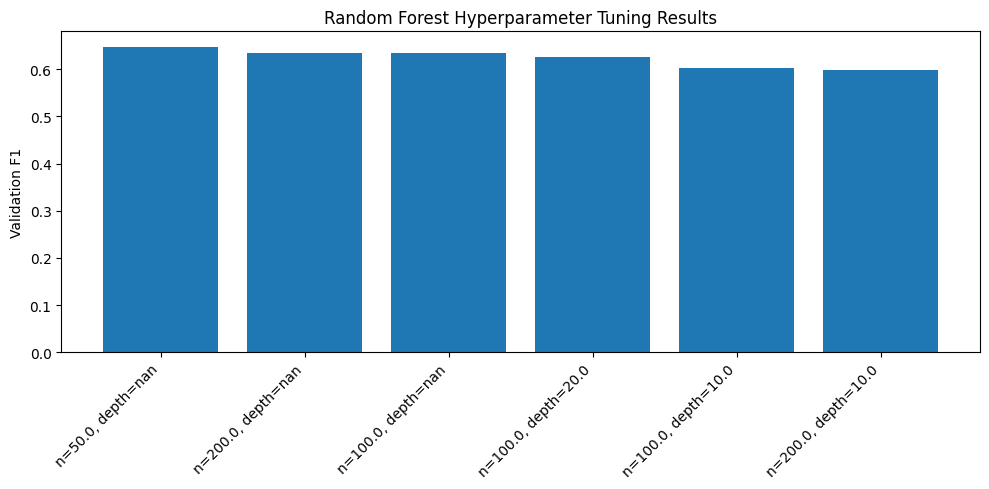

In [11]:
import matplotlib.pyplot as plt

labels = []
for _, row in results_df.iterrows():
    labels.append(f'n={row["n_estimators"]}, depth={row["max_depth"]}')

plt.figure(figsize=(10, 5))
plt.bar(labels, results_df["val_f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation F1")
plt.title("Random Forest Hyperparameter Tuning Results")
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

wine_binary = wine.copy()
wine_binary["quality_binary"] = (wine_binary["quality"] >= 6).astype(int)

X_bin = wine_binary.drop(["quality", "quality_binary"], axis=1)
y_bin = wine_binary["quality_binary"]

seed = 1234

X_train_full_bin, X_test_bin, y_train_full_bin, y_test_bin = train_test_split(
    X_bin,
    y_bin,
    test_size=0.2,
    random_state=seed,
    stratify=y_bin
)

X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X_train_full_bin,
    y_train_full_bin,
    test_size=0.25,
    random_state=seed,
    stratify=y_train_full_bin
)

binary_results = []

param_grid_bin = [
    {"n_estimators": 50, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 20, "min_samples_split": 5, "min_samples_leaf": 2},
]

for params in param_grid_bin:
    rf_bin = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=1234,
        n_jobs=-1
    )

    rf_bin.fit(X_train_bin, y_train_bin)

    y_train_bin_pred = rf_bin.predict(X_train_bin)
    y_val_bin_pred = rf_bin.predict(X_val_bin)

    binary_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "train_accuracy": accuracy_score(y_train_bin, y_train_bin_pred),
        "val_accuracy": accuracy_score(y_val_bin, y_val_bin_pred),
        "val_precision": precision_score(y_val_bin, y_val_bin_pred, zero_division=0),
        "val_recall": recall_score(y_val_bin, y_val_bin_pred, zero_division=0),
        "val_f1": f1_score(y_val_bin, y_val_bin_pred, zero_division=0)
    })

binary_results_df = pd.DataFrame(binary_results)
binary_results_df = binary_results_df.sort_values(by="val_f1", ascending=False).reset_index(drop=True)
binary_results_df

,n_estimators,max_depth,min_samples_split,min_samples_leaf,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
0,100,NaN,2,1,1.000000,0.825385,0.853919,0.873633,0.863664
1,200,NaN,2,1,1.000000,0.821538,0.845614,0.878493,0.861740
2,100,20.0,5,2,0.984604,0.819231,0.843458,0.877278,0.860036
3,50,NaN,2,1,0.999487,0.818462,0.851497,0.863913,0.857660
4,100,10.0,2,1,0.923274,0.800769,0.827907,0.865128,0.846108
5,200,10.0,2,1,0.923531,0.795385,0.823461,0.861482,0.842043


In [13]:
best_params_bin = binary_results_df.iloc[0]
best_params_bin

n_estimators         100.000000
max_depth                   NaN
min_samples_split      2.000000
min_samples_leaf       1.000000
train_accuracy         1.000000
val_accuracy           0.825385
val_precision          0.853919
val_recall             0.873633
val_f1                 0.863664
Name: 0, dtype: float64

In [14]:
best_rf_bin = RandomForestClassifier(
    n_estimators=int(best_params_bin["n_estimators"]),
    max_depth=None if pd.isna(best_params_bin["max_depth"]) else int(best_params_bin["max_depth"]),
    min_samples_split=int(best_params_bin["min_samples_split"]),
    min_samples_leaf=int(best_params_bin["min_samples_leaf"]),
    random_state=1234,
    n_jobs=-1
)

best_rf_bin.fit(X_train_full_bin, y_train_full_bin)

y_train_full_bin_pred = best_rf_bin.predict(X_train_full_bin)
y_test_bin_pred = best_rf_bin.predict(X_test_bin)

train_acc_bin = accuracy_score(y_train_full_bin, y_train_full_bin_pred)
test_acc_bin = accuracy_score(y_test_bin, y_test_bin_pred)
test_precision_bin = precision_score(y_test_bin, y_test_bin_pred, zero_division=0)
test_recall_bin = recall_score(y_test_bin, y_test_bin_pred, zero_division=0)
test_f1_bin = f1_score(y_test_bin, y_test_bin_pred, zero_division=0)

print("Best Parameters:")
print(best_params_bin)
print("\nBinary Classification Results:")
print("train_acc:", train_acc_bin)
print("val_acc:", best_params_bin["val_accuracy"])
print("test_acc:", test_acc_bin)
print("precision:", test_precision_bin)
print("recall:", test_recall_bin)
print("f1:", test_f1_bin)

Best Parameters:
n_estimators         100.000000
max_depth                   NaN
min_samples_split      2.000000
min_samples_leaf       1.000000
train_accuracy         1.000000
val_accuracy           0.825385
val_precision          0.853919
val_recall             0.873633
val_f1                 0.863664
Name: 0, dtype: float64

Binary Classification Results:
train_acc: 1.0
val_acc: 0.8253846153846154
test_acc: 0.8353846153846154
precision: 0.848
recall: 0.9015795868772782
f1: 0.8739693757361602
